## Continuación del modelado para volume

1. trabajar únicamente con los materiales para los que existe una estructura cristalina;
2. generar **un único split train / validation / test agrupado por `framework_formula`**;
3. utilizar exactamente ese mismo split para todos los modelos;
4. construir un baseline tabular basado únicamente en composición;
5. comparar progresivamente distintas representaciones de grafos:
   - GCN con número atómico;
   - GCN con propiedades atómicas;
   - GINE con propiedades atómicas y distancias;
   - GINE con transformación logarítmica del target;
   - GINE con expansión RBF de las distancias;
6. estudiar el efecto del cutoff;
7. seleccionar los modelos usando validation;
8. utilizar test una sola vez para la comparación final;
9. analizar especialmente los materiales con grandes cambios de volumen.

> **Importante:** todos los imports se encuentran en una única celda, inmediatamente debajo.

In [2]:

import copy
import math
import random
import time
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression


from xgboost import XGBRegressor, XGBClassifier


from pymatgen.core import Element


import torch
import torch.nn as nn


from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv,
    GINEConv,
    global_mean_pool,
)

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

c:\venvs\battery_gnn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cpu
CUDA disponible: False


### 1. Configuración

In [3]:
SEED = 42

DATA_PATH = Path("datos_baterias_mp/gnn_dataset.pkl")

TARGET = "max_delta_volume"
GROUP_COL = "framework_formula"
ION_COL = "working_ion_dataset"

TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

BATCH_SIZE = 32
MAX_EPOCHS = 250
PATIENCE = 30

DEFAULT_CUTOFF = 4.0
RBF_DIM = 16

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()


### 2. Carga del dataset y comprobaciones

In [4]:
gnn_df = pd.read_pickle(DATA_PATH).copy()

required_columns = {
    "battery_formula",
    GROUP_COL,
    ION_COL,
    TARGET,
    "structure",
}

missing = required_columns - set(gnn_df.columns)

if missing:
    raise ValueError(
        f"Faltan columnas necesarias en el dataset: {sorted(missing)}"
    )


gnn_df = gnn_df.dropna(
    subset=[GROUP_COL, TARGET, "structure"]
).reset_index(drop=True)

print("Número de materiales:", len(gnn_df))
print("Número de frameworks:", gnn_df[GROUP_COL].nunique())
print("Número de iones:", gnn_df[ION_COL].nunique())

display(
    gnn_df[
        [
            "battery_formula",
            GROUP_COL,
            ION_COL,
            TARGET,
            "n_atoms",
            "volume",
        ]
    ].head()
)

Número de materiales: 3476
Número de frameworks: 1985
Número de iones: 10


,battery_formula,framework_formula,working_ion_dataset,max_delta_volume,n_atoms,volume
0,Cs0-3Ac,Ac,Cs,6.270133,1.0,45.384600
1,Ca0-3Ac,Ac,Ca,2.709372,1.0,45.384600
2,Na0-3Ag,Ag,Na,5.098846,1.0,18.004938
3,Li0-3Ag,Ag,Li,2.736089,1.0,18.004938
4,Mg5-149Ag,Ag,Mg,26.114803,1.0,125.756281


### 3. Agrupación del dataset por `framework_formula`
El objetivo es impedir que una misma familia estructural aparezca simultáneamente en entrenamiento y evaluación.

In [ ]:
all_idx = np.arange(len(gnn_df))
groups = gnn_df[GROUP_COL].to_numpy()

split_1 = GroupShuffleSplit(
    n_splits=1,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=SEED,
)

train_idx, temp_idx = next(
    split_1.split(
        all_idx,
        groups=groups,
    )
)


temp_groups = groups[temp_idx]

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

split_2 = GroupShuffleSplit(
    n_splits=1,
    test_size=relative_test_size,
    random_state=SEED,
)

val_rel_idx, test_rel_idx = next(
    split_2.split(
        temp_idx,
        groups=temp_groups,
    )
)

val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]


train_groups = set(gnn_df.iloc[train_idx][GROUP_COL])
val_groups = set(gnn_df.iloc[val_idx][GROUP_COL])
test_groups = set(gnn_df.iloc[test_idx][GROUP_COL])

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

print()
print("Frameworks train:", len(train_groups))
print("Frameworks validation:", len(val_groups))
print("Frameworks test:", len(test_groups))

Train: 2428
Validation: 515
Test: 533

Frameworks train: 1389
Frameworks validation: 298
Frameworks test: 298


### 4. Comprobar la distribución del target en cada split

In [6]:
def describe_split(name, indices):
    values = gnn_df.iloc[indices][TARGET].to_numpy(dtype=float)

    return {
        "split": name,
        "n": len(values),
        "mean": values.mean(),
        "median": np.median(values),
        "std": values.std(),
        "p95": np.quantile(values, 0.95),
        "p99": np.quantile(values, 0.99),
        "max": values.max(),
        "n_ge_1": int((values >= 1).sum()),
        "n_ge_10": int((values >= 10).sum()),
    }

split_summary = pd.DataFrame(
    [
        describe_split("train", train_idx),
        describe_split("validation", val_idx),
        describe_split("test", test_idx),
    ]
)

display(split_summary)

,split,n,mean,median,std,p95,p99,max,n_ge_1,n_ge_10
0,train,2428,0.806998,0.054800,9.331249,1.824238,13.066698,293.193218,146,34
1,validation,515,0.215458,0.055002,1.132162,0.279513,5.800870,17.497218,10,1
2,test,533,0.434734,0.065928,3.010616,1.431734,6.270115,60.585409,29,4


### 5. Modelo tabular teniendo en cuenta el mismo dataset anterior pero ahora agrupado por framework_formula

In [7]:
ELEMENT_PROPERTIES = [
    "Z",
    "atomic_mass",
    "electronegativity",
    "atomic_radius",
    "row",
    "group",
]

def safe_element_value(element, property_name):
    if property_name == "Z":
        value = element.Z

    elif property_name == "atomic_mass":
        value = element.atomic_mass

    elif property_name == "electronegativity":
        value = element.X

    elif property_name == "atomic_radius":
        value = element.atomic_radius

    elif property_name == "row":
        value = element.row

    elif property_name == "group":
        value = element.group

    else:
        raise ValueError(property_name)

    if value is None:
        return np.nan

    return float(value)


def weighted_stats(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = np.isfinite(values)

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return {
            "mean": 0.0,
            "std": 0.0,
            "min": 0.0,
            "max": 0.0,
        }

    weights = weights / weights.sum()

    mean = np.sum(weights * values)
    variance = np.sum(weights * (values - mean) ** 2)

    return {
        "mean": float(mean),
        "std": float(np.sqrt(variance)),
        "min": float(values.min()),
        "max": float(values.max()),
    }


def composition_features(structure):
    composition = structure.composition.element_composition

    elements = list(composition.elements)

    amounts = np.array(
        [composition[element] for element in elements],
        dtype=float,
    )

    fractions = amounts / amounts.sum()

    features = {
        "n_elements": len(elements),
        "composition_entropy": float(
            -np.sum(
                fractions * np.log(fractions + 1e-12)
            )
        ),
    }

    for property_name in ELEMENT_PROPERTIES:
        values = [
            safe_element_value(element, property_name)
            for element in elements
        ]

        stats = weighted_stats(
            values,
            fractions,
        )

        for stat_name, value in stats.items():
            features[
                f"{property_name}_{stat_name}"
            ] = value

    return features

In [8]:
tabular_rows = []

for _, row in gnn_df.iterrows():
    features = composition_features(
        row["structure"]
    )

    features[ION_COL] = row[ION_COL]

    tabular_rows.append(features)

X_tabular = pd.DataFrame(tabular_rows)
y_all = gnn_df[TARGET].to_numpy(dtype=float)

print("Shape X_tabular:", X_tabular.shape)

display(X_tabular.head())

Shape X_tabular: (3476, 27)


,n_elements,composition_entropy,Z_mean,Z_std,Z_min,Z_max,atomic_mass_mean,atomic_mass_std,atomic_mass_min,atomic_mass_max,...,atomic_radius_max,row_mean,row_std,row_min,row_max,group_mean,group_std,group_min,group_max,working_ion_dataset
0,1,-1.000089e-12,89.0,0.0,89.0,89.0,227.0000,0.0,227.0000,227.0000,...,1.95,7.0,0.0,7.0,7.0,3.0,0.0,3.0,3.0,Cs
1,1,-1.000089e-12,89.0,0.0,89.0,89.0,227.0000,0.0,227.0000,227.0000,...,1.95,7.0,0.0,7.0,7.0,3.0,0.0,3.0,3.0,Ca
2,1,-1.000089e-12,47.0,0.0,47.0,47.0,107.8682,0.0,107.8682,107.8682,...,1.60,5.0,0.0,5.0,5.0,11.0,0.0,11.0,11.0,Na
3,1,-1.000089e-12,47.0,0.0,47.0,47.0,107.8682,0.0,107.8682,107.8682,...,1.60,5.0,0.0,5.0,5.0,11.0,0.0,11.0,11.0,Li
4,1,-1.000089e-12,47.0,0.0,47.0,47.0,107.8682,0.0,107.8682,107.8682,...,1.60,5.0,0.0,5.0,5.0,11.0,0.0,11.0,11.0,Mg


### 6. Definición de las métricas comunes

In [9]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "MedAE": median_absolute_error(
            y_true,
            y_pred,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),
        "R2": r2_score(
            y_true,
            y_pred,
        ),
    }


def metrics_row(name, split_name, y_true, y_pred):
    return {
        "model": name,
        "split": split_name,
        **regression_metrics(
            y_true,
            y_pred,
        ),
    }

### 7. Modelo Dummy

In [10]:
X_train_tab = X_tabular.iloc[train_idx]
X_val_tab = X_tabular.iloc[val_idx]
X_test_tab = X_tabular.iloc[test_idx]

y_train = y_all[train_idx]
y_val = y_all[val_idx]
y_test = y_all[test_idx]

dummy = DummyRegressor(
    strategy="median"
)

dummy.fit(
    np.zeros((len(train_idx), 1)),
    y_train,
)

dummy_val_pred = dummy.predict(
    np.zeros((len(val_idx), 1))
)

dummy_val_metrics = metrics_row(
    "Dummy median",
    "validation",
    y_val,
    dummy_val_pred,
)

display(
    pd.DataFrame(
        [dummy_val_metrics]
    )
)

,model,split,MAE,MedAE,RMSE,R2
0,Dummy median,validation,0.190979,0.036679,1.143504,-0.020137


### 8. Modelo XGBoost: target original y `log1p`

In [11]:
numeric_columns = [
    column
    for column in X_tabular.columns
    if column != ION_COL
]

categorical_columns = [ION_COL]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns,
        ),
        (
            "ion",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_columns,
        ),
    ],
    remainder="drop",
)

def make_xgb_pipeline():
    return Pipeline(
        steps=[
            (
                "preprocess",
                copy.deepcopy(preprocessor),
            ),
            (
                "model",
                XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.03,
                    max_depth=5,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    reg_lambda=1.0,
                    objective="reg:squarederror",
                    random_state=SEED,
                    n_jobs=-1,
                ),
            ),
        ]
    )

In [ ]:
# XGBoost original

xgb_original = make_xgb_pipeline()

xgb_original.fit(
    X_train_tab,
    y_train,
)

xgb_original_val_pred = xgb_original.predict(
    X_val_tab
)

# XGBoost log1p

xgb_log = make_xgb_pipeline()

xgb_log.fit(
    X_train_tab,
    np.log1p(y_train),
)

xgb_log_val_pred = np.expm1(
    xgb_log.predict(
        X_val_tab
    )
)

tabular_val_results = pd.DataFrame(
    [
        dummy_val_metrics,
        metrics_row(
            "XGB composición",
            "validation",
            y_val,
            xgb_original_val_pred,
        ),
        metrics_row(
            "XGB composición + log1p",
            "validation",
            y_val,
            xgb_log_val_pred,
        ),
    ]
).sort_values("RMSE")

display(tabular_val_results)

,model,split,MAE,MedAE,RMSE,R2
2,XGB composición + log1p,validation,0.130322,0.035322,0.889109,0.383273
1,XGB composición,validation,0.184223,0.040987,1.051865,0.136818
0,Dummy median,validation,0.190979,0.036679,1.143504,-0.020137


In [13]:
TABULAR_MODELS = {
    "XGB composición": xgb_original,
    "XGB composición + log1p": xgb_log,
}

best_tabular_name = (
    tabular_val_results[
        tabular_val_results["model"].str.startswith("XGB")
    ]
    .sort_values("RMSE")
    .iloc[0]["model"]
)

best_tabular_model = TABULAR_MODELS[
    best_tabular_name
]

print(
    "Mejor baseline tabular según RMSE de validation:",
    best_tabular_name,
)

Mejor baseline tabular según RMSE de validation: XGB composición + log1p


#### 9. Representación de las estructuras cristalinas como GRAFO

### `z`: 
Solo número atómico. Es el baseline estructural mínimo.

### `atomic4`:
- número atómico;
- masa atómica;
- electronegatividad;
- radio atómico.

In [14]:
def atom_features(site, mode="atomic4"):
    element = Element(
        site.specie.symbol
    )

    if mode == "z":
        return [
            float(element.Z)
        ]

    if mode == "atomic4":
        return [
            float(element.Z),
            float(element.atomic_mass),
            float(element.X)
            if element.X is not None
            else 0.0,
            float(element.atomic_radius)
            if element.atomic_radius is not None
            else 0.0,
        ]

    raise ValueError(
        f"node feature mode desconocido: {mode}"
    )


def get_node_features(
    structure,
    mode="atomic4",
):
    return torch.tensor(
        [
            atom_features(
                site,
                mode=mode,
            )
            for site in structure
        ],
        dtype=torch.float32,
    )

### 10. Representación de las distancias
Distancia directa y Expansión RBF

In [15]:
def gaussian_rbf(
    distances,
    cutoff,
    num_centers=RBF_DIM,
):
    centers = torch.linspace(
        0.0,
        cutoff,
        num_centers,
        dtype=torch.float32,
    )

    delta = centers[1] - centers[0]

    gamma = 1.0 / (
        delta ** 2 + 1e-12
    )

    distances = distances.view(-1, 1)

    return torch.exp(
        -gamma
        * (
            distances
            - centers.view(1, -1)
        ) ** 2
    )

### 11. Construcción de grafos periódicos

En una estructura periódica, un vecino puede tener el mismo índice que el átomo central y, sin embargo, corresponder a una imagen periódica de otra celda.
`pymatgen.get_neighbors` ya excluye el propio sitio central a distancia cero, por lo que se conservan sus imágenes periódicas.

In [16]:
def structure_to_graph(
    structure,
    target,
    cutoff=4.0,
    node_mode="atomic4",
    edge_mode="distance",
):
    # Nodos
    x = get_node_features(
        structure,
        mode=node_mode,
    )

    edges = []
    distances = []


    # Vecinos periódicos
    for i in range(
        len(structure)
    ):
        neighbors = structure.get_neighbors(
            structure[i],
            cutoff,
        )

        for neighbor in neighbors:
            j = int(
                neighbor.index
            )

            distance = float(
                neighbor.nn_distance
            )

            edges.append(
                [i, j]
            )

            distances.append(
                distance
            )

    # Aristas
    if len(edges) == 0:
        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long,
        )

        if edge_mode == "rbf":
            edge_attr = torch.empty(
                (0, RBF_DIM),
                dtype=torch.float32,
            )
        else:
            edge_attr = torch.empty(
                (0, 1),
                dtype=torch.float32,
            )

    else:
        edge_index = torch.tensor(
            edges,
            dtype=torch.long,
        ).t().contiguous()

        distance_tensor = torch.tensor(
            distances,
            dtype=torch.float32,
        )

        if edge_mode == "distance":
            edge_attr = (
                distance_tensor
                .view(-1, 1)
            )

        elif edge_mode == "rbf":
            edge_attr = gaussian_rbf(
                distance_tensor,
                cutoff=cutoff,
                num_centers=RBF_DIM,
            )

        elif edge_mode == "none":
            edge_attr = (
                distance_tensor
                .view(-1, 1)
            )

        else:
            raise ValueError(
                f"edge_mode desconocido: {edge_mode}"
            )

    y = torch.tensor(
        [float(target)],
        dtype=torch.float32,
    )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
    )

### 12. Creación y normalización de datasets de grafos

In [17]:
def normalize_graph_node_features(
    train_graphs,
    val_graphs,
    test_graphs,
):
    train_graphs = copy.deepcopy(
        train_graphs
    )

    val_graphs = copy.deepcopy(
        val_graphs
    )

    test_graphs = copy.deepcopy(
        test_graphs
    )

    train_nodes = torch.cat(
        [
            graph.x
            for graph
            in train_graphs
        ],
        dim=0,
    )

    mean = train_nodes.mean(
        dim=0
    )

    std = train_nodes.std(
        dim=0
    ).clamp_min(
        1e-8
    )

    for graph_list in [
        train_graphs,
        val_graphs,
        test_graphs,
    ]:
        for graph in graph_list:
            graph.x = (
                graph.x - mean
            ) / std

    return (
        train_graphs,
        val_graphs,
        test_graphs,
        mean,
        std,
    )


def transform_graph_targets(
    graph_list,
    target_transform,
):
    graph_list = copy.deepcopy(
        graph_list
    )

    if target_transform == "none":
        return graph_list

    if target_transform == "log1p":
        for graph in graph_list:
            graph.y = torch.log1p(
                graph.y
            )

        return graph_list

    raise ValueError(
        target_transform
    )


def build_graph_dataset(
    cutoff,
    node_mode,
    edge_mode,
    target_transform,
):
    all_graphs = []

    for _, row in gnn_df.iterrows():
        graph = structure_to_graph(
            structure=row["structure"],
            target=row[TARGET],
            cutoff=cutoff,
            node_mode=node_mode,
            edge_mode=edge_mode,
        )

        all_graphs.append(
            graph
        )

    train_graphs = [
        all_graphs[i]
        for i in train_idx
    ]

    val_graphs = [
        all_graphs[i]
        for i in val_idx
    ]

    test_graphs = [
        all_graphs[i]
        for i in test_idx
    ]

    (
        train_graphs,
        val_graphs,
        test_graphs,
        node_mean,
        node_std,
    ) = normalize_graph_node_features(
        train_graphs,
        val_graphs,
        test_graphs,
    )

    train_graphs = transform_graph_targets(
        train_graphs,
        target_transform,
    )

    val_graphs = transform_graph_targets(
        val_graphs,
        target_transform,
    )

    test_graphs = transform_graph_targets(
        test_graphs,
        target_transform,
    )

    return {
        "train_graphs": train_graphs,
        "val_graphs": val_graphs,
        "test_graphs": test_graphs,
        "node_mean": node_mean,
        "node_std": node_std,
    }


def make_loaders(
    graph_dataset,
    batch_size=BATCH_SIZE,
):
    return {
        "train": DataLoader(
            graph_dataset["train_graphs"],
            batch_size=batch_size,
            shuffle=True,
        ),
        "val": DataLoader(
            graph_dataset["val_graphs"],
            batch_size=batch_size,
            shuffle=False,
        ),
        "test": DataLoader(
            graph_dataset["test_graphs"],
            batch_size=batch_size,
            shuffle=False,
        ),
    }

### 13. Modelos


In [18]:
class GCNBattery(nn.Module):
    def __init__(
        self,
        node_dim,
        hidden_channels=64,
        dropout=0.10,
    ):
        super().__init__()

        self.conv1 = GCNConv(
            node_dim,
            hidden_channels,
        )

        self.conv2 = GCNConv(
            hidden_channels,
            hidden_channels,
        )

        self.conv3 = GCNConv(
            hidden_channels,
            hidden_channels,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.head = nn.Sequential(
            nn.Linear(
                hidden_channels,
                64,
            ),
            nn.ReLU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                64,
                1,
            ),
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch,
    ):
        x = torch.relu(
            self.conv1(
                x,
                edge_index,
            )
        )

        x = self.dropout(x)

        x = torch.relu(
            self.conv2(
                x,
                edge_index,
            )
        )

        x = self.dropout(x)

        x = torch.relu(
            self.conv3(
                x,
                edge_index,
            )
        )

        x = global_mean_pool(
            x,
            batch,
        )

        return self.head(
            x
        ).squeeze(-1)


class GINEBattery(nn.Module):
    def __init__(
        self,
        node_dim,
        edge_dim,
        hidden_channels=64,
        dropout=0.10,
    ):
        super().__init__()

        self.node_encoder = nn.Linear(
            node_dim,
            hidden_channels,
        )

        def make_mlp():
            return nn.Sequential(
                nn.Linear(
                    hidden_channels,
                    hidden_channels,
                ),
                nn.ReLU(),
                nn.Linear(
                    hidden_channels,
                    hidden_channels,
                ),
            )

        self.conv1 = GINEConv(
            make_mlp(),
            edge_dim=edge_dim,
        )

        self.conv2 = GINEConv(
            make_mlp(),
            edge_dim=edge_dim,
        )

        self.conv3 = GINEConv(
            make_mlp(),
            edge_dim=edge_dim,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.head = nn.Sequential(
            nn.Linear(
                hidden_channels,
                64,
            ),
            nn.ReLU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                64,
                1,
            ),
        )

    def forward(
        self,
        x,
        edge_index,
        edge_attr,
        batch,
    ):
        x = self.node_encoder(
            x
        )

        x = torch.relu(
            self.conv1(
                x,
                edge_index,
                edge_attr,
            )
        )

        x = self.dropout(x)

        x = torch.relu(
            self.conv2(
                x,
                edge_index,
                edge_attr,
            )
        )

        x = self.dropout(x)

        x = torch.relu(
            self.conv3(
                x,
                edge_index,
                edge_attr,
            )
        )

        x = global_mean_pool(
            x,
            batch,
        )

        return self.head(
            x
        ).squeeze(-1)

### 14. Funciones de entrenamiento

Se utiliza:
- Huber loss;
- AdamW;
- gradient clipping;
- early stopping.

La mejor época se determina exclusivamente con validation.

In [19]:
def make_model(
    architecture,
    node_dim,
    edge_dim,
    hidden_channels=64,
    dropout=0.10,
):
    if architecture == "GCN":
        return GCNBattery(
            node_dim=node_dim,
            hidden_channels=hidden_channels,
            dropout=dropout,
        )

    if architecture == "GINE":
        return GINEBattery(
            node_dim=node_dim,
            edge_dim=edge_dim,
            hidden_channels=hidden_channels,
            dropout=dropout,
        )

    raise ValueError(
        architecture
    )


def run_loss_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):
    is_training = (
        optimizer is not None
    )

    model.train(
        is_training
    )

    total_loss = 0.0
    total_graphs = 0

    context = (
        torch.enable_grad()
        if is_training
        else torch.no_grad()
    )

    with context:
        for batch in loader:
            batch = batch.to(
                DEVICE
            )

            if is_training:
                optimizer.zero_grad()

            prediction = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr,
                batch.batch,
            )

            loss = criterion(
                prediction,
                batch.y,
            )

            if is_training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0,
                )

                optimizer.step()

            total_loss += (
                loss.item()
                * batch.num_graphs
            )

            total_graphs += (
                batch.num_graphs
            )

    return (
        total_loss
        / total_graphs
    )


def train_gnn(
    model,
    train_loader,
    val_loader,
    lr=1e-3,
    weight_decay=1e-5,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
):
    criterion = nn.HuberLoss(
        delta=1.0
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_val_loss = np.inf
    best_state = None
    best_epoch = None

    wait = 0
    history = []

    for epoch in range(
        1,
        max_epochs + 1,
    ):
        train_loss = run_loss_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        val_loss = run_loss_epoch(
            model,
            val_loader,
            criterion,
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
            }
        )

        if val_loss < (
            best_val_loss - 1e-6
        ):
            best_val_loss = val_loss
            best_epoch = epoch

            best_state = {
                key: value.detach()
                .cpu()
                .clone()
                for key, value
                in model.state_dict().items()
            }

            wait = 0

        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is None:
        raise RuntimeError(
            "No se guardó ningún estado del modelo."
        )

    model.load_state_dict(
        best_state
    )

    model.to(
        DEVICE
    )

    return (
        model,
        pd.DataFrame(history),
        best_epoch,
        best_val_loss,
    )

### 15. Predicción y conversión a escala original de `log1p`

In [20]:
def inverse_target(
    values,
    target_transform,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    if target_transform == "none":
        return values

    if target_transform == "log1p":
        return np.expm1(
            values
        )

    raise ValueError(
        target_transform
    )


def predict_gnn(
    model,
    loader,
    target_transform,
):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(
                DEVICE
            )

            prediction = model(
                batch.x,
                batch.edge_index,
                batch.edge_attr,
                batch.batch,
            )

            y_true.extend(
                batch.y
                .detach()
                .cpu()
                .numpy()
            )

            y_pred.extend(
                prediction
                .detach()
                .cpu()
                .numpy()
            )

    y_true = inverse_target(
        y_true,
        target_transform,
    )

    y_pred = inverse_target(
        y_pred,
        target_transform,
    )

    return (
        y_true,
        y_pred,
    )

### 16. Evaluación de modelos

| Experimento | Pregunta |
|---|---|
| GCN-Z | ¿qué aprende la GNN con una representación mínima? |
| GCN-atomic4 | ¿mejoran las propiedades fisicoquímicas de los nodos? |
| GINE-distance | ¿aporta información la geometría explícita? |
| GINE-distance-log | ¿ayuda `log1p` dentro de la GNN? |
| GINE-RBF | ¿una representación más rica de la distancia mejora el modelo? |


In [21]:
EXPERIMENTS = [
    {
        "name": "GCN_Z",
        "architecture": "GCN",
        "node_mode": "z",
        "edge_mode": "none",
        "target_transform": "none",
        "cutoff": DEFAULT_CUTOFF,
        "hidden_channels": 64,
        "dropout": 0.10,
        "lr": 1e-3,
    },
    {
        "name": "GCN_atomic4",
        "architecture": "GCN",
        "node_mode": "atomic4",
        "edge_mode": "none",
        "target_transform": "none",
        "cutoff": DEFAULT_CUTOFF,
        "hidden_channels": 64,
        "dropout": 0.10,
        "lr": 1e-3,
    },
    {
        "name": "GINE_distance",
        "architecture": "GINE",
        "node_mode": "atomic4",
        "edge_mode": "distance",
        "target_transform": "none",
        "cutoff": DEFAULT_CUTOFF,
        "hidden_channels": 64,
        "dropout": 0.10,
        "lr": 1e-3,
    },
    {
        "name": "GINE_distance_log1p",
        "architecture": "GINE",
        "node_mode": "atomic4",
        "edge_mode": "distance",
        "target_transform": "log1p",
        "cutoff": DEFAULT_CUTOFF,
        "hidden_channels": 64,
        "dropout": 0.10,
        "lr": 1e-3,
    },
]

display(
    pd.DataFrame(
        EXPERIMENTS
    )
)

,name,architecture,node_mode,edge_mode,target_transform,cutoff,hidden_channels,dropout,lr
0,GCN_Z,GCN,z,none,none,4.0,64,0.1,0.001
1,GCN_atomic4,GCN,atomic4,none,none,4.0,64,0.1,0.001
2,GINE_distance,GINE,atomic4,distance,none,4.0,64,0.1,0.001
3,GINE_distance_log1p,GINE,atomic4,distance,log1p,4.0,64,0.1,0.001


### 17. Función para ejecutar un experimento

Los modelos, historiales y predicciones de validation se guardan para poder analizarlos posteriormente sin volver a entrenar.

In [22]:
def run_experiment(config):
    set_seed(SEED)

    start_time = time.time()

    graph_dataset = build_graph_dataset(
        cutoff=config["cutoff"],
        node_mode=config["node_mode"],
        edge_mode=config["edge_mode"],
        target_transform=config[
            "target_transform"
        ],
    )

    loaders = make_loaders(
        graph_dataset
    )

    sample_graph = (
        graph_dataset[
            "train_graphs"
        ][0]
    )

    node_dim = (
        sample_graph.x.shape[1]
    )

    edge_dim = (
        sample_graph.edge_attr.shape[1]
    )

    model = make_model(
        architecture=config[
            "architecture"
        ],
        node_dim=node_dim,
        edge_dim=edge_dim,
        hidden_channels=config[
            "hidden_channels"
        ],
        dropout=config[
            "dropout"
        ],
    ).to(
        DEVICE
    )

    (
        model,
        history,
        best_epoch,
        best_val_loss,
    ) = train_gnn(
        model=model,
        train_loader=loaders["train"],
        val_loader=loaders["val"],
        lr=config["lr"],
    )

    y_val_true, y_val_pred = (
        predict_gnn(
            model,
            loaders["val"],
            config[
                "target_transform"
            ],
        )
    )

    metrics = regression_metrics(
        y_val_true,
        y_val_pred,
    )

    elapsed = (
        time.time() - start_time
    )

    result = {
        "name": config["name"],
        "architecture": config[
            "architecture"
        ],
        "node_mode": config[
            "node_mode"
        ],
        "edge_mode": config[
            "edge_mode"
        ],
        "target_transform": config[
            "target_transform"
        ],
        "cutoff": config[
            "cutoff"
        ],
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "seconds": elapsed,
        **metrics,
    }

    artifact = {
        "config": copy.deepcopy(
            config
        ),
        "model": model,
        "history": history,
        "graph_dataset": graph_dataset,
        "loaders": loaders,
        "val_true": y_val_true,
        "val_pred": y_val_pred,
    }

    return result, artifact

In [23]:
experiment_results = []
experiment_artifacts = {}

for config in EXPERIMENTS:
    print(
        f"\n{'=' * 70}"
    )
    print(
        "Experimento:",
        config["name"],
    )
    print(
        f"{'=' * 70}"
    )

    result, artifact = (
        run_experiment(
            config
        )
    )

    experiment_results.append(
        result
    )

    experiment_artifacts[
        config["name"]
    ] = artifact

    print(
        pd.Series(
            result
        )[
            [
                "MAE",
                "MedAE",
                "RMSE",
                "R2",
                "best_epoch",
            ]
        ]
    )

gnn_val_results = (
    pd.DataFrame(
        experiment_results
    )
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    gnn_val_results
)


Experimento: GCN_Z
MAE           0.174785
MedAE         0.054405
RMSE          0.999286
R2            0.220955
best_epoch          91
dtype: object

Experimento: GCN_atomic4
MAE           0.136994
MedAE         0.037091
RMSE          0.640825
R2            0.679623
best_epoch         104
dtype: object

Experimento: GINE_distance
MAE           0.140434
MedAE         0.050863
RMSE          0.671687
R2            0.648021
best_epoch          42
dtype: object

Experimento: GINE_distance_log1p
MAE           0.147441
MedAE         0.060957
RMSE          0.686948
R2            0.631846
best_epoch          98
dtype: object


,name,architecture,node_mode,edge_mode,target_transform,cutoff,best_epoch,best_val_loss,seconds,MAE,MedAE,RMSE,R2
0,GCN_atomic4,GCN,atomic4,none,none,4.0,104,0.073761,279.322779,0.136994,0.037091,0.640825,0.679623
1,GINE_distance,GINE,atomic4,distance,none,4.0,42,0.072923,198.503125,0.140434,0.050863,0.671687,0.648021
2,GINE_distance_log1p,GINE,atomic4,distance,log1p,4.0,98,0.010260,325.839551,0.147441,0.060957,0.686948,0.631846
3,GCN_Z,GCN,z,none,none,4.0,91,0.103308,241.887764,0.174785,0.054405,0.999286,0.220955


### 18. Curvas de entrenamiento y validación

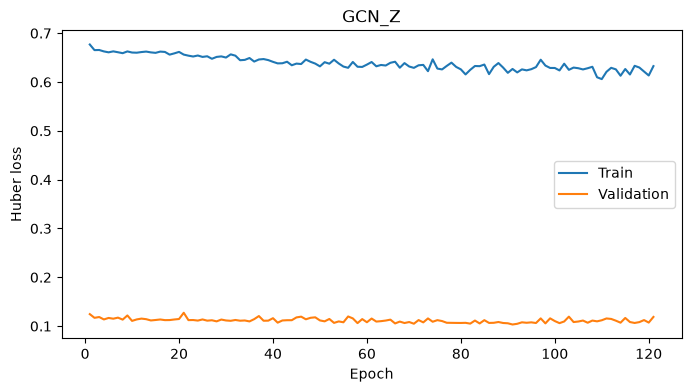

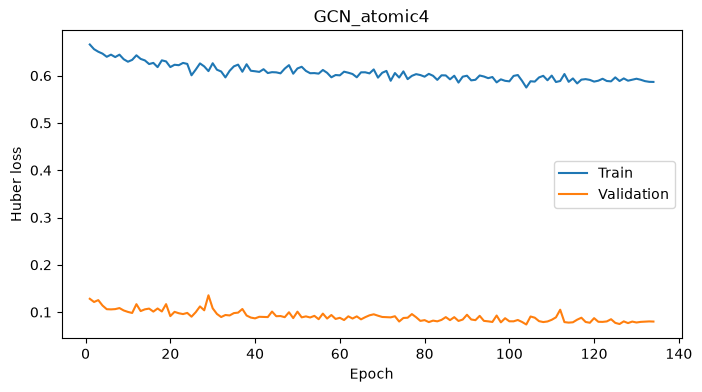

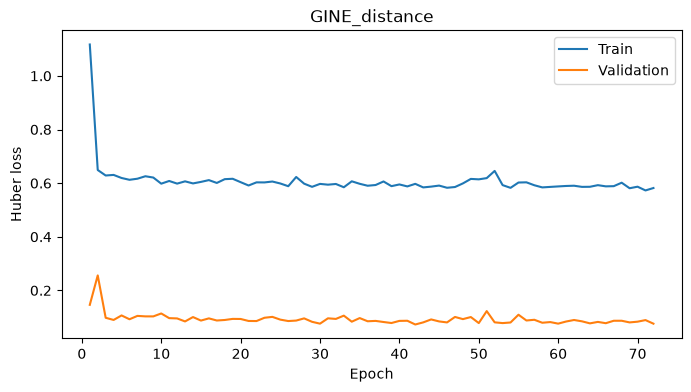

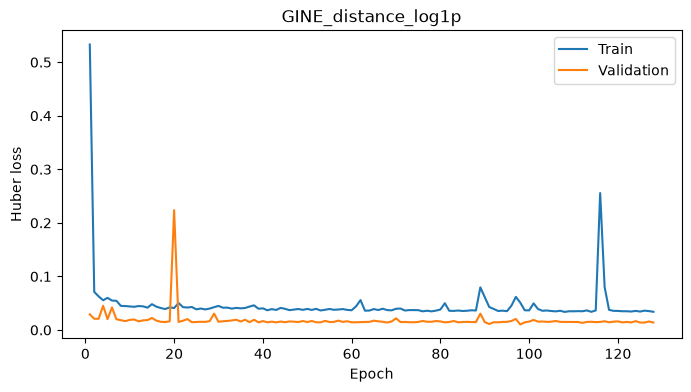

In [24]:
for model_name, artifact in experiment_artifacts.items():
    history = artifact["history"]

    fig, ax = plt.subplots(
        figsize=(8, 4)
    )

    ax.plot(
        history["epoch"],
        history["train_loss"],
        label="Train",
    )

    ax.plot(
        history["epoch"],
        history["val_loss"],
        label="Validation",
    )

    ax.set_xlabel(
        "Epoch"
    )

    ax.set_ylabel(
        "Huber loss"
    )

    ax.set_title(
        model_name
    )

    ax.legend()

    plt.show()

### 19. Comparación de validaciones

- `GCN_Z` vs `GCN_atomic4`;
- `GCN_atomic4` vs `GINE_distance`;
- `GINE_distance` vs `GINE_distance_log1p`;
- `GINE_distance` vs `GINE_RBF`.

In [25]:
comparison_val = pd.concat(
    [
        tabular_val_results[
            [
                "model",
                "MAE",
                "MedAE",
                "RMSE",
                "R2",
            ]
        ],
        gnn_val_results[
            [
                "name",
                "MAE",
                "MedAE",
                "RMSE",
                "R2",
            ]
        ].rename(
            columns={
                "name": "model"
            }
        ),
    ],
    ignore_index=True,
).sort_values(
    "RMSE"
)

display(
    comparison_val
)

,model,MAE,MedAE,RMSE,R2
3,GCN_atomic4,0.136994,0.037091,0.640825,0.679623
4,GINE_distance,0.140434,0.050863,0.671687,0.648021
5,GINE_distance_log1p,0.147441,0.060957,0.686948,0.631846
0,XGB composición + log1p,0.130322,0.035322,0.889109,0.383273
6,GCN_Z,0.174785,0.054405,0.999286,0.220955
1,XGB composición,0.184223,0.040987,1.051865,0.136818
2,Dummy median,0.190979,0.036679,1.143504,-0.020137


### 20. Estudio del error en `max_delta_volume`

Se separan tres regímenes interpretables:
- `< 0.1`;
- `0.1 – 1`;
- `>= 1`.

In [26]:
def make_error_dataframe(
    indices,
    y_true,
    y_pred,
):
    result = gnn_df.iloc[
        indices
    ][
        [
            "battery_formula",
            GROUP_COL,
            ION_COL,
            TARGET,
            "n_atoms",
            "volume",
        ]
    ].copy()

    result = result.reset_index(
        drop=False
    ).rename(
        columns={
            "index": "dataset_index"
        }
    )

    result["y_true"] = (
        np.asarray(y_true)
    )

    result["y_pred"] = (
        np.asarray(y_pred)
    )

    result["error"] = (
        result["y_pred"]
        - result["y_true"]
    )

    result["abs_error"] = (
        np.abs(
            result["error"]
        )
    )

    result["target_range"] = (
        pd.cut(
            result["y_true"],
            bins=[
                -np.inf,
                0.1,
                1.0,
                np.inf,
            ],
            labels=[
                "< 0.1",
                "0.1 - 1",
                ">= 1",
            ],
        )
    )

    return result

In [27]:
best_gnn_name = (
    gnn_val_results
    .sort_values("RMSE")
    .iloc[0]["name"]
)

best_gnn_artifact = (
    experiment_artifacts[
        best_gnn_name
    ]
)

val_error_df = (
    make_error_dataframe(
        val_idx,
        best_gnn_artifact[
            "val_true"
        ],
        best_gnn_artifact[
            "val_pred"
        ],
    )
)

print(
    "Mejor GNN en validation:",
    best_gnn_name,
)

display(
    val_error_df.groupby(
        "target_range",
        observed=True,
    ).agg(
        n=(
            "abs_error",
            "size",
        ),
        MAE=(
            "abs_error",
            "mean",
        ),
        median_error=(
            "abs_error",
            "median",
        ),
        max_true=(
            "y_true",
            "max",
        ),
    )
)

Mejor GNN en validation: GCN_atomic4


,n,MAE,median_error,max_true
target_range,,,,
< 0.1,382,0.039909,0.028436,0.099117
0.1 - 1,123,0.135916,0.092924,0.607657
>= 1,10,3.858905,4.095517,17.497217


### 21. Estudio del error por ion

In [28]:
val_by_ion = (
    val_error_df.groupby(
        ION_COL
    )
    .agg(
        n=(
            "abs_error",
            "size",
        ),
        MAE=(
            "abs_error",
            "mean",
        ),
        MedAE=(
            "abs_error",
            "median",
        ),
        max_target=(
            "y_true",
            "max",
        ),
    )
    .sort_values(
        "n",
        ascending=False,
    )
)

display(
    val_by_ion
)

,n,MAE,MedAE,max_target
working_ion_dataset,,,,
Li,198,0.054938,0.032120,0.466413
Mg,152,0.115241,0.038068,9.216420
Ca,54,0.336683,0.039886,5.872814
Zn,43,0.191850,0.043177,7.231260
Na,25,0.091472,0.035072,0.313615
Y,13,0.108687,0.055138,0.372084
K,12,0.120508,0.097926,0.534047
Al,9,0.629593,0.036951,17.497217
Cs,6,0.756929,0.181286,8.904740


### 22. Test final

In [29]:

# Mejor modelo tabular

if best_tabular_name == "XGB composición + log1p":
    tabular_test_pred = np.expm1(
        best_tabular_model.predict(X_test_tab)
    )
else:
    tabular_test_pred = best_tabular_model.predict(
        X_test_tab
    )


# Mejor modelo GNN

final_gnn_name = "GINE_distance"

final_gnn_artifact = experiment_artifacts[
    final_gnn_name
]

final_gnn_model = final_gnn_artifact["model"]

final_gnn_loaders = final_gnn_artifact[
    "loaders"
]

final_gnn_transform = final_gnn_artifact[
    "config"
]["target_transform"]


gnn_test_true, gnn_test_pred = predict_gnn(
    final_gnn_model,
    final_gnn_loaders["test"],
    final_gnn_transform,
)


assert np.allclose(
    gnn_test_true,
    y_test
)



final_test_results = pd.DataFrame(
    [
        metrics_row(
            best_tabular_name,
            "test",
            y_test,
            tabular_test_pred,
        ),
        metrics_row(
            final_gnn_name,
            "test",
            y_test,
            gnn_test_pred,
        ),
    ]
)

display(final_test_results)

,model,split,MAE,MedAE,RMSE,R2
0,XGB composición + log1p,test,0.404324,0.040017,3.046667,-0.024093
1,GINE_distance,test,0.376147,0.058131,2.906740,0.067816


### 22. Mejora de GNN respecto al modelo tabular

Se calcula el error de ambos modelos para cada material y se estudia:
- cambio pequeño;
- cambio intermedio;
- cambio elevado.

In [30]:
comparison_test = (
    gnn_df.iloc[
        test_idx
    ][
        [
            "battery_formula",
            GROUP_COL,
            ION_COL,
            TARGET,
            "n_atoms",
            "volume",
        ]
    ]
    .copy()
    .reset_index(
        drop=False
    )
    .rename(
        columns={
            "index": "dataset_index"
        }
    )
)

comparison_test[
    "pred_tabular"
] = tabular_test_pred

comparison_test[
    "pred_gnn"
] = gnn_test_pred

comparison_test[
    "error_tabular"
] = np.abs(
    comparison_test[
        "pred_tabular"
    ]
    - comparison_test[
        TARGET
    ]
)

comparison_test[
    "error_gnn"
] = np.abs(
    comparison_test[
        "pred_gnn"
    ]
    - comparison_test[
        TARGET
    ]
)

comparison_test[
    "gnn_improvement"
] = (
    comparison_test[
        "error_tabular"
    ]
    - comparison_test[
        "error_gnn"
    ]
)

comparison_test[
    "target_range"
] = pd.cut(
    comparison_test[
        TARGET
    ],
    bins=[
        -np.inf,
        0.1,
        1.0,
        np.inf,
    ],
    labels=[
        "< 0.1",
        "0.1 - 1",
        ">= 1",
    ],
)

display(
    comparison_test.groupby(
        "target_range",
        observed=True,
    ).agg(
        n=(
            TARGET,
            "size",
        ),
        MAE_tabular=(
            "error_tabular",
            "mean",
        ),
        MAE_GNN=(
            "error_gnn",
            "mean",
        ),
        mejora_media_GNN=(
            "gnn_improvement",
            "mean",
        ),
    )
)

,n,MAE_tabular,MAE_GNN,mejora_media_GNN
target_range,,,,
< 0.1,341,0.064360,0.085290,-0.020930
0.1 - 1,163,0.180179,0.136067,0.044112
>= 1,29,5.661673,5.145636,0.516037


### 23. Comparación por ion en test

In [31]:
test_by_ion = (
    comparison_test.groupby(
        ION_COL
    )
    .agg(
        n=(
            TARGET,
            "size",
        ),
        MAE_tabular=(
            "error_tabular",
            "mean",
        ),
        MAE_GNN=(
            "error_gnn",
            "mean",
        ),
        max_target=(
            TARGET,
            "max",
        ),
    )
    .sort_values(
        "n",
        ascending=False,
    )
)

display(
    test_by_ion
)

,n,MAE_tabular,MAE_GNN,max_target
working_ion_dataset,,,,
Li,208,0.104037,0.091797,2.381496
Mg,151,0.981407,0.775850,60.585409
Ca,50,0.176538,0.206767,3.001009
Zn,37,0.306671,0.531479,6.816085
Na,35,0.055307,0.157529,2.637930
Y,15,0.313585,0.216965,4.231674
K,13,0.084372,0.391070,5.109929
Al,10,0.108477,0.512404,0.222472
Rb,8,0.662323,0.167695,1.405160


### 24. Gráfico real vs predicho del modelo final

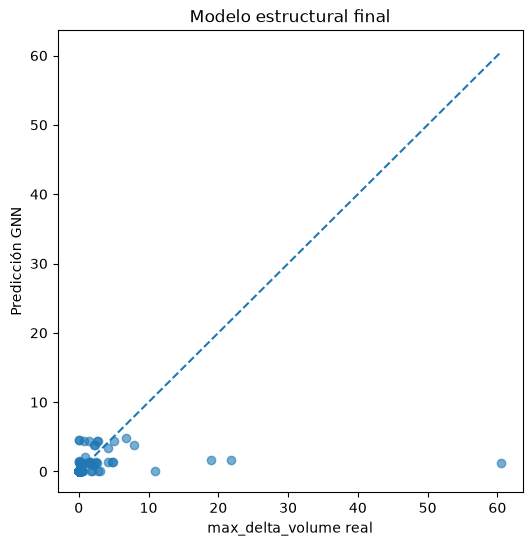

In [32]:
fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.scatter(
    y_test,
    gnn_test_pred,
    alpha=0.60,
)

minimum = min(
    y_test.min(),
    gnn_test_pred.min(),
)

maximum = max(
    y_test.max(),
    gnn_test_pred.max(),
)

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
)

ax.set_xlabel(
    "max_delta_volume real"
)

ax.set_ylabel(
    "Predicción GNN"
)

ax.set_title(
    "Modelo estructural final"
)

plt.show()

### 25. Residuos del modelo final

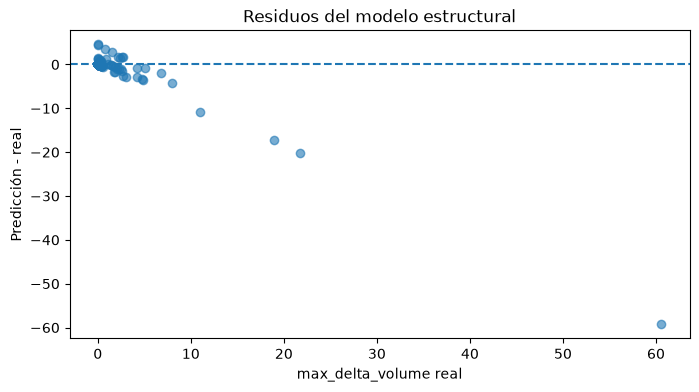

In [33]:
residuals = (
    gnn_test_pred
    - y_test
)

fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.scatter(
    y_test,
    residuals,
    alpha=0.60,
)

ax.axhline(
    0,
    linestyle="--",
)

ax.set_xlabel(
    "max_delta_volume real"
)

ax.set_ylabel(
    "Predicción - real"
)

ax.set_title(
    "Residuos del modelo estructural"
)

plt.show()

### 26. Casos en los que el error absoluto de la GNN es menor que el modelo tabular

In [34]:
display(
    comparison_test.sort_values(
        "gnn_improvement",
        ascending=False,
    ).head(25)
)

,dataset_index,battery_formula,framework_formula,working_ion_dataset,max_delta_volume,n_atoms,volume,pred_tabular,pred_gnn,error_tabular,error_gnn,gnn_improvement,target_range
478,3123,Mg0-7Nb,Nb,Mg,7.944308,1.0,18.935514,34.751328,3.798514,26.807019,4.145795,22.661224,>= 1
15,114,Li0-1Cs7Au5O2,Cs7Au5O2,Li,0.054714,14.0,536.429939,6.833140,1.322537,6.778426,1.267823,5.510603,< 0.1
280,1955,Mg2-3Ca,Ca,Mg,0.281604,2.0,168.575082,5.554969,0.600019,5.273365,0.318415,4.954950,0.1 - 1
279,1954,Mg1-2Ca,Ca,Mg,0.346122,2.0,125.802019,5.554969,0.951297,5.208846,0.605174,4.603672,0.1 - 1
53,314,Rb0-1Bi,Bi,Rb,1.405160,1.0,35.219721,5.620511,1.251366,4.215351,0.153794,4.061556,>= 1
276,1951,Mg0-3Ca,Ca,Mg,1.471595,1.0,43.681039,5.554969,1.406660,4.083374,0.064935,4.018439,>= 1
477,3122,Li0-3Nb,Nb,Li,2.381496,1.0,18.935514,6.852797,3.798514,4.471301,1.417018,3.054283,>= 1
289,2002,Y0-1Cd3Pd,Cd3Pd,Y,4.231674,8.0,154.812849,1.626978,3.429563,2.604695,0.802111,1.802584,>= 1
48,309,Mg5-7Bi,Bi,Mg,0.293191,1.0,147.689176,2.225330,0.582304,1.932139,0.289113,1.643026,0.1 - 1
23,129,Ca0-0.08BH,BH,Ca,0.026038,48.0,484.966142,1.719969,0.085989,1.693931,0.059951,1.633980,< 0.1


### 27. Casos en los que el error absoluto de la GNN es mayor que el modelo tabular

In [35]:
display(
    comparison_test.sort_values(
        "gnn_improvement",
        ascending=True,
    ).head(25)
)

,dataset_index,battery_formula,framework_formula,working_ion_dataset,max_delta_volume,n_atoms,volume,pred_tabular,pred_gnn,error_tabular,error_gnn,gnn_improvement,target_range
268,1885,Al0-1Zr5Sb3,Zr5Sb3,Al,0.060800,16.0,364.500821,0.633859,4.607898,0.573059,4.547098,-3.974039,< 0.1
278,1953,Mg5-149Ca,Ca,Mg,21.757673,1.0,152.234186,5.554969,1.607314,16.202704,20.150359,-3.947655,>= 1
267,1884,Zn0-1Zr5Sb3,Zr5Sb3,Zn,0.051044,16.0,364.500821,0.795118,4.607898,0.744075,4.556854,-3.812780,< 0.1
285,1960,Zn0-3Ca,Ca,Zn,0.810422,1.0,41.761181,0.840745,4.420682,0.030324,3.610260,-3.579937,0.1 - 1
286,1961,K0-3Ca,Ca,K,4.790403,1.0,43.681039,5.009525,1.406660,0.219122,3.383743,-3.164621,>= 1
277,1952,Mg1-15Ca,Ca,Mg,4.858431,1.0,65.513556,5.554969,1.411706,0.696538,3.446725,-2.750187,>= 1
275,1950,Li0-3Ca,Ca,Li,1.513956,1.0,41.761181,2.195585,4.420682,0.681629,2.906726,-2.225097,>= 1
54,315,Ca0-1.5Bi,Bi,Ca,2.222402,1.0,31.705611,2.223563,3.879572,0.001161,1.657170,-1.656009,>= 1
274,1949,Na0-3Ca,Ca,Na,2.637930,1.0,41.761181,2.471328,4.420682,0.166603,1.782752,-1.616149,>= 1
270,1887,Cs0-2Se,Se,Cs,10.950215,1.0,20.491668,1.575849,0.085989,9.374366,10.864226,-1.489860,>= 1


### 28. Tablas finales

In [36]:
print("TABLA FINAL: VALIDATION")
display(
    comparison_val
)

print("TABLA FINAL: TEST")
display(
    final_test_results
)

print("TABLA FINAL: RANGOS DEL TARGET")
display(
    comparison_test.groupby(
        "target_range",
        observed=True,
    ).agg(
        n=(TARGET, "size"),
        MAE_tabular=(
            "error_tabular",
            "mean",
        ),
        MAE_GNN=(
            "error_gnn",
            "mean",
        ),
        mejora_GNN=(
            "gnn_improvement",
            "mean",
        ),
    )
)

TABLA FINAL: VALIDATION


,model,MAE,MedAE,RMSE,R2
3,GCN_atomic4,0.136994,0.037091,0.640825,0.679623
4,GINE_distance,0.140434,0.050863,0.671687,0.648021
5,GINE_distance_log1p,0.147441,0.060957,0.686948,0.631846
0,XGB composición + log1p,0.130322,0.035322,0.889109,0.383273
6,GCN_Z,0.174785,0.054405,0.999286,0.220955
1,XGB composición,0.184223,0.040987,1.051865,0.136818
2,Dummy median,0.190979,0.036679,1.143504,-0.020137


TABLA FINAL: TEST


,model,split,MAE,MedAE,RMSE,R2
0,XGB composición + log1p,test,0.404324,0.040017,3.046667,-0.024093
1,GINE_distance,test,0.376147,0.058131,2.906740,0.067816


TABLA FINAL: RANGOS DEL TARGET


,n,MAE_tabular,MAE_GNN,mejora_GNN
target_range,,,,
< 0.1,341,0.064360,0.085290,-0.020930
0.1 - 1,163,0.180179,0.136067,0.044112
>= 1,29,5.661673,5.145636,0.516037


### 29. Guardado de datos

In [37]:
MODEL_DIR = Path("modelos_finales")
MODEL_DIR.mkdir(exist_ok=True)


final_gnn_name = "GINE_distance"

final_gnn_artifact = experiment_artifacts[
    final_gnn_name
]

final_gnn_model = final_gnn_artifact[
    "model"
]

final_gnn_config = final_gnn_artifact[
    "config"
]

final_gnn_graph_dataset = final_gnn_artifact[
    "graph_dataset"
]

# Normalización calculada únicamente con train
node_mean = final_gnn_graph_dataset[
    "node_mean"
]

node_std = final_gnn_graph_dataset[
    "node_std"
]


checkpoint = {
    "model_name": final_gnn_name,

    "model_state_dict": (
        final_gnn_model
        .state_dict()
    ),

    "node_mean": (
        node_mean
        .detach()
        .cpu()
    ),

    "node_std": (
        node_std
        .detach()
        .cpu()
    ),

    "architecture": (
        final_gnn_config[
            "architecture"
        ]
    ),

    "node_mode": (
        final_gnn_config[
            "node_mode"
        ]
    ),

    "edge_mode": (
        final_gnn_config[
            "edge_mode"
        ]
    ),

    "target_transform": (
        final_gnn_config[
            "target_transform"
        ]
    ),

    "cutoff": (
        final_gnn_config[
            "cutoff"
        ]
    ),

    "hidden_channels": (
        final_gnn_config[
            "hidden_channels"
        ]
    ),

    "dropout": (
        final_gnn_config[
            "dropout"
        ]
    ),

    "node_dim": 4,
    "edge_dim": 1,
}

torch.save(
    checkpoint,
    MODEL_DIR / "gine_distance_volume.pt"
)

print(
    "Modelo guardado en:",
    MODEL_DIR / "gine_distance_volume.pt"
)

Modelo guardado en: modelos_finales\gine_distance_volume.pt
